In [2]:
!wget 'https://drive.google.com/uc?id=1dhh4m9VRLUSmbaHfge2iRSW5Azkpefco' -O kitty3.png
!wget 'https://drive.google.com/uc?id=1o0UMPTyUFzX9CaQp-BwYXgkCho1Zo6yL' -O kitty55.png
!wget 'https://drive.google.com/uc?id=1Jk0cEtQt4HxkLcKlmTHukpb22gJZ4dmL' -O noisy_kitty55.png
!wget 'https://drive.google.com/uc?id=1xCNA5338nzj1GgGQ5-oBA1dKCW1Mvn21' -O hillbefore_noise10%.jpg


--2025-10-18 13:30:33--  https://drive.google.com/uc?id=1dhh4m9VRLUSmbaHfge2iRSW5Azkpefco
Resolving drive.google.com (drive.google.com)... 142.250.66.110
Connecting to drive.google.com (drive.google.com)|142.250.66.110|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1dhh4m9VRLUSmbaHfge2iRSW5Azkpefco [following]
--2025-10-18 13:30:33--  https://drive.usercontent.google.com/download?id=1dhh4m9VRLUSmbaHfge2iRSW5Azkpefco
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.204.65
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.204.65|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1194851 (1.1M) [image/png]
Saving to: ‘kitty3.png’

kitty3.png          100%[===================>]   1.14M  4.58MB/s    in 0.2s    

2025-10-18 13:30:35 (4.58 MB/s) - ‘kitty3.png’ saved [1194851/1194851]

--2025-10-18 13:30:36--  https://drive.

In [3]:
import cv2

img = cv2.imread('kitty3.png')
print(img.shape)
img = cv2.imread('kitty55.png')
print(img.shape)
img = cv2.imread('noisy_kitty55.png')
print(img.shape)


(1000, 1000, 3)
(500, 500, 3)
(500, 500, 3)


# L10 Object Recognition Part I

In [4]:
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import data, exposure
import cv2
import numpy as np

## Histogram of Oriented Gradient (HOG)

* simple image

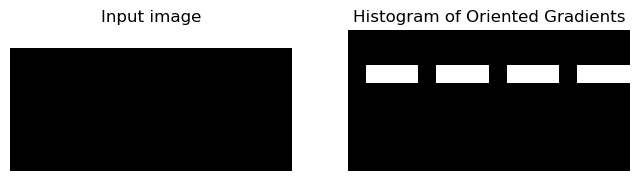

In [5]:
image = np.array(
    [
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    ]
)

fd, hog_image = hog(
    image,
    orientations=5,
    pixels_per_cell=(4, 4),
    cells_per_block=(2, 2),
    visualize=True,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

ax1.axis("off")
ax1.imshow(image, cmap=plt.cm.gray)
ax1.set_title("Input image")

# Rescale histogram for better display
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

ax2.axis("off")
ax2.imshow(hog_image, cmap=plt.cm.gray)
ax2.set_title("Histogram of Oriented Gradients")
plt.show()

In [6]:
print(fd.shape)

(60,)


* Astronaut image

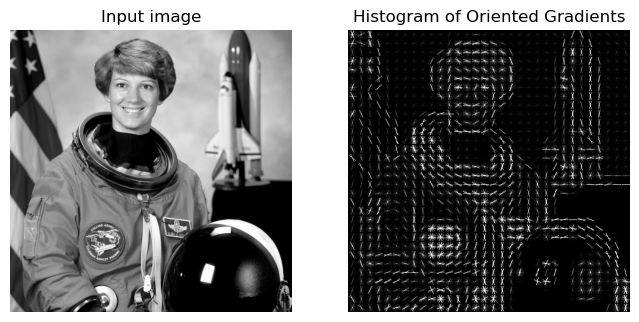

In [7]:
image = data.astronaut()
image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)


# TO DO : Select different orientaion, pixels_per_cell and cells_per_block and analyze the results
fd, hog_image = hog(image, orientations=9, pixels_per_cell=(16, 16), cells_per_block=(2, 2), visualize=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(image, cmap=plt.cm.gray)
ax1.set_title('Input image')

# Rescale histogram for better display
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

ax2.axis('off')
ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')
plt.show()

## HOG + Neural Networks

* MNIST dataset

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import hog
from keras.datasets import mnist

# ----------------------------
# 1. Load MNIST dataset
# ----------------------------
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# ----------------------------
# 2. Split train / validation / test sets
# ----------------------------
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

# ----------------------------
# 3. Preprocessing
# ----------------------------
# Normalize pixel values to [0, 1]
x_train = x_train / 255.0
x_val = x_val / 255.0
x_test = x_test / 255.0

# ----------------------------
# 4. Compute HOG features
# ----------------------------
def extract_hog_features(images):
    features = []
    for img in images:
        hog_feature = hog(
            img,
            orientations=9,
            pixels_per_cell=(7, 7),
            cells_per_block=(2, 2)
        )
        features.append(hog_feature)
    return np.array(features)

print("Computing HOG features ...")
X_train_hog = extract_hog_features(x_train)
X_val_hog   = extract_hog_features(x_val)
X_test_hog  = extract_hog_features(x_test)

print("HOG feature shape:", X_train_hog.shape)

# ----------------------------
# 5. Build Neural Network model
# ----------------------------
model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    batch_size=128,
    max_iter=20,
    random_state=42,
    verbose = 1
)

# ----------------------------
# 6. Train the model
# ----------------------------
print("Training Neural Network ...")
model.fit(X_train_hog, y_train)

# ----------------------------
# 7. Evaluate performance
# ----------------------------
y_pred_val = model.predict(X_val_hog)
y_pred_test = model.predict(X_test_hog)

print("Validation accuracy:", accuracy_score(y_val, y_pred_val))
print("Test accuracy:", accuracy_score(y_test, y_pred_test))
print("\nClassification Report (Test):\n", classification_report(y_test, y_pred_test))


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Computing HOG features ...
HOG feature shape: (48000, 324)
Training Neural Network ...
Iteration 1, loss = 0.39965454
Iteration 2, loss = 0.13205272
Iteration 3, loss = 0.10939313
Iteration 4, loss = 0.09458296
Iteration 5, loss = 0.08354383
Iteration 6, loss = 0.07584269
Iteration 7, loss = 0.06858298
Iteration 8, loss = 0.06354502
Iteration 9, loss = 0.05883747
Iteration 10, loss = 0.05294656
Iteration 11, loss = 0.04910805
Iteration 12, loss = 0.04470576
Iteration 13, loss = 0.04213044
Iteration 14, loss = 0.04005390
Iteration 15, loss = 0.03596592
Iteration 16, loss = 0.03377508
Iteration 17, loss = 0.03133425
Iteration 18, loss = 0.02915637
Iteration 19, loss = 0.02724999
Iteration 20, loss = 0.02469732
Validation accuracy: 0.9773333333333334
Test accuracy: 0.9767

Classification Report (Test):
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99     

/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


* Inferencing

[9]


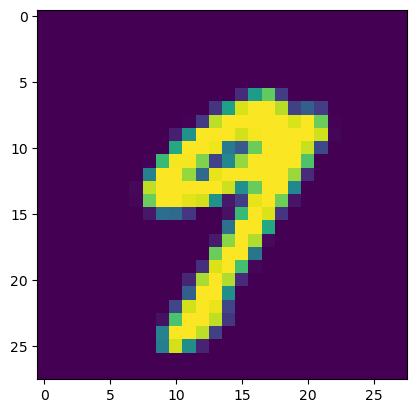

In [12]:
fd_test = hog(x_test[20].reshape((28,28))/255.0, orientations=9, pixels_per_cell=(7,7),cells_per_block=(2,2))
print(model.predict(fd_test.reshape(1,324)))

plt.imshow(x_test[20])
plt.show()

In [13]:
fd_test.shape

(324,)

## Convolutional Neural Networks (CNN)

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets
from torchvision.transforms import ToTensor
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchsummary import summary

**Note:** If you encounter import errors with PyTorch, restart the kernel (Kernel → Restart Kernel) to load the newly installed packages.

### Prep data

In [2]:
train_data = datasets.MNIST(
    root = 'data',
    train = True,
    transform = ToTensor(),
    download = True,
)
test_data = datasets.MNIST(
    root = 'data',
    train = False,
    transform = ToTensor()
)

train_data, val_data = random_split(train_data,[50000,10000])


batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(train_data, batch_size=batch_size)
val_dataloader = DataLoader(val_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in train_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

for X, y in val_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break


Failed to download (trying next):
HTTP Error 404: Not Found

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:05<00:00, 1932202.23it/s]



Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 102089.82it/s]



Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:02<00:00, 694209.57it/s]



Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 5325839.75it/s]

Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64
Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64
Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


In [3]:
print((5*5*1+1)*16)

416


### Prep model

In [4]:
# Creating Models
# Get cpu or gpu device for training.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=5,
                stride=1,
                padding=2,
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, 5, 1, 2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        # fully connected layer, output 10 classes
        self.out = nn.Linear(32 * 7 * 7, 10)
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)

        # flatten the output of conv2 to (batch_size, 32 * 7 * 7)
        x = x.view(x.size(0), -1)
        output = F.log_softmax(self.out(x), dim=1)
        return output




model = Net().to(device)
print(model)

summary(model, input_size=(1, 28, 28))

# Optimizing the Model Parameters
loss_fn = nn.CrossEntropyLoss()
# optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)


Using cpu device
Net(
  (conv1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (out): Linear(in_features=1568, out_features=10, bias=True)
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 28, 28]             416
              ReLU-2           [-1, 16, 28, 28]               0
         MaxPool2d-3           [-1, 16, 14, 14]               0
            Conv2d-4           [-1, 32, 14, 14]          12,832
              ReLU-5           [-1, 32, 14, 14]               0
         MaxPool2d-6             [-1, 32, 7, 7]               

In [5]:
print((5*5*1 + 1)*16)

416


In [6]:
print((5*5*1 + 1)*16)
print((5*5*16 + 1)*32)
print((7*7*32+1)*10)
print()

416
12832
15690



### Training

In [7]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)

        # print(type(pred),type(y))
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")



def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Accuracy: {(100*correct):>0.1f}%,  Avg loss: {test_loss:>8f} \n")

def val(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Val Accuracy: {(100*correct):>0.1f}%,  Avg loss: {test_loss:>8f} \n")

epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    val(val_dataloader, model, loss_fn)
print("Done!")


Epoch 1
-------------------------------
loss: 2.289672  [    0/50000]
loss: 0.145075  [ 6400/50000]
loss: 0.145075  [ 6400/50000]
loss: 0.190516  [12800/50000]
loss: 0.190516  [12800/50000]
loss: 0.088539  [19200/50000]
loss: 0.088539  [19200/50000]
loss: 0.188611  [25600/50000]
loss: 0.188611  [25600/50000]
loss: 0.085190  [32000/50000]
loss: 0.085190  [32000/50000]
loss: 0.103870  [38400/50000]
loss: 0.103870  [38400/50000]
loss: 0.085966  [44800/50000]
loss: 0.085966  [44800/50000]
Val Accuracy: 97.5%,  Avg loss: 0.083695 

Epoch 2
-------------------------------
loss: 0.045847  [    0/50000]
Val Accuracy: 97.5%,  Avg loss: 0.083695 

Epoch 2
-------------------------------
loss: 0.045847  [    0/50000]
loss: 0.167110  [ 6400/50000]
loss: 0.167110  [ 6400/50000]
loss: 0.029939  [12800/50000]
loss: 0.029939  [12800/50000]
loss: 0.036433  [19200/50000]
loss: 0.036433  [19200/50000]
loss: 0.173392  [25600/50000]
loss: 0.173392  [25600/50000]
loss: 0.128224  [32000/50000]
loss: 0.128224

### Inferencing

In [8]:
torch.save(model.state_dict(), "model.pth")
print("Saved PyTorch Model State to model.pth")

_model = Net().to(device)
weights=torch.load("model.pth")
_model.load_state_dict(weights)

print("Test accuracy")
test(test_dataloader, _model, loss_fn)


Saved PyTorch Model State to model.pth
Test accuracy
Test Accuracy: 97.8%,  Avg loss: 0.074622 

Test Accuracy: 97.8%,  Avg loss: 0.074622 

